# **Pertanyaan Bisnis**

1. Bagaimana tren kebutuhan skill IT pada berbagai role industri, serta skill apa yang bersifat universal dan spesifik pada masing-masing role?
2. Bagaimana karakteristik kepemilikan skill kandidat pada berbagai role IT?
3. Bagaimana gap skill antara Kebutuhan Industri dengan Kandidat?

# **Eksploratory Data Analysis**

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
import gdown
import re
warnings.filterwarnings('ignore')
from datasets import load_dataset

In [ ]:
RED_DARK = ['#660000', '#990000', '#CC0000', '#E63946', '#FF4D4D']
BG_LIGHT = '#FAF7F7'

def make_gradient(n):
    cmap = mcolors.LinearSegmentedColormap.from_list("red_dark", RED_DARK)
    return [mcolors.to_hex(c) for c in cmap(np.linspace(0.05, 0.95, n))]

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'x',
    'grid.alpha'       : 0.35,
    'axes.labelsize'   : 11,
    'axes.titlesize'   : 12,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})

## **Data Wrangling**

### **Gathering Data**

##### **Memuat tabel job description**

In [ ]:
file_jd = '13_tLGL1b2Drk6F-ep9Xc3_wTzrzydrJh'
url_jd = f'https://drive.google.com/uc?id={file_jd}'
df_jd = pd.read_csv(url_jd)

##### **Memuat tabel cv1**

In [ ]:
url_cv1 = load_dataset("InferencePrince555/Resume-Dataset")
df_cv1 = pd.DataFrame(url_cv1['train'])

it_categories = [
    'Generate a Resume for a Database Administrator Job',
    'Generate a Resume for a Network Administrator Job',
    'Generate a Resume for a Security Analyst Job',
    'Generate a Resume for a Systems Administrator Job',
    'Generate a Resume for a Web Developer Job',
]

df_cv1 = df_cv1[df_cv1['instruction'].isin(it_categories)]

##### **Memuat tabel cv2**

In [ ]:
file_cv2 = '1OYAMOF53gybBIGy7QBzJ5Y8Hoq58NfLI'
url_cv2 = f'https://drive.google.com/uc?id={file_cv2}'
output_file = 'dataset_cv2.csv'
gdown.download(url_cv2, output_file, quiet=False)
df_cv2 = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=1OYAMOF53gybBIGy7QBzJ5Y8Hoq58NfLI
From (redirected): https://drive.google.com/uc?id=1OYAMOF53gybBIGy7QBzJ5Y8Hoq58NfLI&confirm=t&uuid=4f8b7227-721b-4573-939b-065678dd66a2
To: /content/dataset_cv2.csv
100%|██████████| 106M/106M [00:01<00:00, 97.6MB/s] 


##### **Memuat tabel cv3**

In [ ]:
file_cv3 = '1hGqPs7xnjXHGn6I2yc5b6mJ5ibtkbV1I'
url_cv3 = f'https://drive.google.com/uc?id={file_cv3}'
df_cv3 = pd.read_csv(url_cv3)

### **Assesing Data**

##### **Menilai tabel job description**

In [ ]:
df_jd.head()

,ID,Query,Job Title,Description,IT Skills,Soft Skills,Education,Experience,Token Usage
0,3859,Artificial Intelligence,Collaborative Manipulation Roboticist,"Location: Schlumberger-Doll Research, Cambridg...","Collaborative Manipulation, Artificial Intelli...","Problem-solving, Organizational skills, Commun...",NaN,These skills are related to experience.,562
1,3764,Artificial Intelligence,Software Engineer - Innovation Lab,About DENSO DENSO is one of the largest global...,"Software Development, Infotainment Systems, Au...","Creativity, Collaboration, Problem-solving, Ad...",NaN,NaN,616
2,3597,Artificial Intelligence,"Director, Standards & Strategy","As a Director of Strategy & Strategy at Xperi,...","Audio/video codec, Media streaming and storage...","Participation in international standards, cons...","Skills Related to Education:, Undergraduate de...","Skills Related to Experience:, Audio/video cod...",549
3,3746,Artificial Intelligence,Business Strategy Consultant,If you have a strategic mindset and expertise ...,"Mobility technological trends expertise, Busin...","Strategic mindset, Thought leadership, Communi...",NaN,NaN,613
4,3872,Artificial Intelligence,Regular Full-Time,Mission Who We Are Founded and continuously le...,"Test planning, Bug tracking tools, Automation ...","Team player, Entrepreneurial mindset, Problem-...",NaN,NaN,1051


Insight:
- Query bisa digunakan untuk mengelompokan job sesuai bidangnya dan kolom Description akan diubah menjadi job desc text

In [ ]:
df_jd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           3000 non-null   int64 
 1   Query        3000 non-null   object
 2   Job Title    3000 non-null   object
 3   Description  3000 non-null   object
 4   IT Skills    2990 non-null   object
 5   Soft Skills  2978 non-null   object
 6   Education    1563 non-null   object
 7   Experience   1572 non-null   object
 8   Token Usage  3000 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 211.1+ KB


Insight:
- Kolom yang digunakan adalah Query dan Description, dari kedua kolom tersebut tidak ada kesalahan tipe data maupun missing value.

##### **Menilai tabel cv1**

In [ ]:
df_cv1.head()

,instruction,input,Resume_test
1501,Generate a Resume for a Database Administrator...,None,WEB DEVELOPER span lWEBspan span lDEVELOPERspa...
1502,Generate a Resume for a Database Administrator...,None,Python Developer span lPythonspan span lDevelo...
1503,Generate a Resume for a Database Administrator...,None,DATABASE ADMINISTRATOR DATABASE span lADMINIST...
1504,Generate a Resume for a Database Administrator...,None,Systems Administrator span lSystemsspan span l...
1505,Generate a Resume for a Database Administrator...,None,Database Administrator span lDatabasespan span...


Insight:
- kolom instruction akan digunakan untuk mengelompokan job sesuai bidangnya dan kolom Resume_test akan diubah menjadi kolom cv_text

##### **Menilai tabel cv2**

In [ ]:
df_cv2.head()

,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...


Insight:
- kolom category akan digunakan untuk mengelompokan job sesuai bidangnya dan kolom Text akan diubah menjadi kolom cv_text

##### **Menilai tabel cv3**

In [ ]:
df_cv3.head()

,Category,Resume
0,Frontend Developer,"As a seasoned Frontend Developer, I have a pro..."
1,Backend Developer,With a solid background in Backend Development...
2,Python Developer,"As a Python Developer, I leverage my expertise..."
3,Data Scientist,"With a background in Data Science, I possess a..."
4,Frontend Developer,Experienced Frontend Developer with a passion ...


Insight:
- kolom Category akan digunakan untuk mengelompokan job sesuai bidangnya dan kolom Resume akan diubah menjadi kolom cv_text

### **Cleaning Data**

##### **Transformasi tabel job description**

menyesuaikan nama kolom dan role pada dataset job description sebelum diproses lebih lanjut

In [ ]:
df_jd = df_jd[['Query', 'Description']].rename(columns={
    'Query': 'job_role',
    'Description': 'job_desc_text'
})
df_jd.head()

,job_role,job_desc_text
0,Artificial Intelligence,"Location: Schlumberger-Doll Research, Cambridg..."
1,Artificial Intelligence,About DENSO DENSO is one of the largest global...
2,Artificial Intelligence,"As a Director of Strategy & Strategy at Xperi,..."
3,Artificial Intelligence,If you have a strategic mindset and expertise ...
4,Artificial Intelligence,Mission Who We Are Founded and continuously le...


In [ ]:
mapping_jd = {
    'Machine Learning': 'Machine Learning Engineer',
    'Artificial Intelligence': 'AI Engineer',
    'Deep Learning': 'Deep Learning Engineer',
    'Data Scientist': 'Data Scientist',
    'Data Analyst': 'Data Analyst',
    'Data Engineer': 'Data Engineer',
    'Database Administrator': 'Database Administrator',
    'Business Analyst': 'Business Analyst',
    'Business Intelligence Analyst': 'BI Analyst',
    'Cloud Services Developer': 'Cloud Engineer',
    'Cloud Architect': 'Cloud Architect',
    'Full Stack Developer': 'Web Developer',
    'Network Architect': 'Network Engineer',
    'Information Security Analyst': 'Cyber Security Analyst',
    'IT Systems Administrator': 'System Administrator',
    'IT Consultant': 'IT Consultant',
    'Technical Operations': 'IT Operations',
    'Technology Integration': 'System Integrator'
}

# 1. Terapkan pemetaan ke df_jd
df_jd['job_role'] = df_jd['job_role'].map(mapping_jd)
df_jd.dropna(inplace=True)
df_jd = df_jd.drop_duplicates(subset=['job_desc_text'])

# 2. Cek hasilnya (Semua role aman terjemahkan tanpa ada yang di-drop ke None)
print(df_jd['job_role'].unique())

['AI Engineer' 'Business Analyst' 'BI Analyst' 'Cloud Architect'
 'Cloud Engineer' 'Data Analyst' 'Data Engineer' 'Data Scientist'
 'Database Administrator' 'Deep Learning Engineer' 'Web Developer'
 'IT Consultant' 'System Administrator' 'Cyber Security Analyst'
 'Machine Learning Engineer' 'Network Engineer' 'IT Operations'
 'System Integrator']


##### **Transformasi tabel cv1**

menyesuaikan nama kolom dan role sebelum digabung dengan dataset cv2 dan cv3

In [ ]:
df_cv1 = df_cv1[['instruction', 'Resume_test']].rename(columns={
    'instruction': 'cv_role',
    'Resume_test': 'cv_text'
})
df_cv1.head()

,cv_role,cv_text
1501,Generate a Resume for a Database Administrator...,WEB DEVELOPER span lWEBspan span lDEVELOPERspa...
1502,Generate a Resume for a Database Administrator...,Python Developer span lPythonspan span lDevelo...
1503,Generate a Resume for a Database Administrator...,DATABASE ADMINISTRATOR DATABASE span lADMINIST...
1504,Generate a Resume for a Database Administrator...,Systems Administrator span lSystemsspan span l...
1505,Generate a Resume for a Database Administrator...,Database Administrator span lDatabasespan span...


In [ ]:
mapping_cv1 = {
    'Generate a Resume for a Database Administrator Job': 'Database Administrator',
    'Generate a Resume for a Network Administrator Job': 'Network Engineer',
    'Generate a Resume for a Security Analyst Job': 'Cyber Security Analyst',
    'Generate a Resume for a Systems Administrator Job': 'System Administrator',
    'Generate a Resume for a Web Developer Job': 'Web Developer'
}
df_cv1['cv_role'] = df_cv1['cv_role'].map(mapping_cv1)

##### **Transformasi tabel cv2**

menyesuaikan nama kolom dan role sebelum digabung dengan dataset cv1 dan cv3

In [ ]:
df_cv2 = df_cv2[['category', 'Text']].rename(columns={
    'category': 'cv_role',
    'Text': 'cv_text'
})
df_cv2.head()

,cv_role,cv_text
0,Java Developers/Architects Resumes,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Overall 7 years of experience in design and de...
3,Java Developers/Architects Resumes,7 + years of experience in Application Analysi...
4,Java Developers/Architects Resumes,With approx 5 years of experience in IT sector...


In [ ]:
mapping_cv2 = {
    'Business Analyst (BA) Resumes': 'Business Analyst',
    'Datawarehousing, ETL, Informatica Resumes': 'Data Engineer',
    'Business Intelligence, Business Object Resumes': 'BI Analyst',
}
df_cv2['cv_role'] = df_cv2['cv_role'].map(mapping_cv2)

##### **Transformasi tabel cv3**

menyesuaikan nama kolom dan role sebelum digabung dengan dataset cv1 dan cv2

In [ ]:
df_cv3 = df_cv3[['Category', 'Resume']].rename(columns={
    'Category': 'cv_role',
    'Resume': 'cv_text'
})
df_cv3.head()

,cv_role,cv_text
0,Frontend Developer,"As a seasoned Frontend Developer, I have a pro..."
1,Backend Developer,With a solid background in Backend Development...
2,Python Developer,"As a Python Developer, I leverage my expertise..."
3,Data Scientist,"With a background in Data Science, I possess a..."
4,Frontend Developer,Experienced Frontend Developer with a passion ...


In [ ]:
mapping_cv3 = {
    'Data Scientist': 'Data Scientist',
    'Machine Learning Engineer': 'Machine Learning Engineer',
    'Cloud Engineer': 'Cloud Engineer',
}
df_cv3['cv_role'] = df_cv3['cv_role'].map(mapping_cv3)

##### **Merging tabel cv**

menggabungkan 3 dataset cv menjadi 1 agar mudah diproses

In [ ]:
df_cv = pd.concat([df_cv1, df_cv2, df_cv3], ignore_index=True)
df_cv.dropna(inplace=True)
df_cv = df_cv.drop_duplicates(subset=['cv_text'])

##### **Ekstraksi skill**

melakukan ekstraksi skill dari kolom job_desc_text dan cv_text untuk mendapatkan daftar skill yang dibutuhkan dan dimiliki untuk proses eksplorasi data

In [ ]:
IT_SKILLS_LIST = [
    # Programming Languages
    'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'c',
    'r', 'scala', 'go', 'rust', 'perl', 'php', 'ruby', 'swift',
    'kotlin', 'matlab', 'bash', 'shell scripting', 'shell', 'powershell',
    'vba', 'scripting', 'programming', 'html5', 'css3', 'xml', 'json', 'yaml',

    # Web Frontend
    'html', 'css', 'react', 'angular', 'vue', 'sass', 'bootstrap',
    'tailwind css', 'webpack', 'vite', 'figma', 'adobe xd', 'jquery',

    # Web Backend
    'node.js', 'nodejs', 'express', 'django', 'flask', 'fastapi',
    'spring boot', 'spring', 'hibernate', 'laravel', 'ruby on rails',
    '.net', 'asp.net', 'web development', 'software development',
    'software engineering', 'application development',

    # Database
    'microsoft sql server', 'sql server', 'mysql', 'postgresql', 'mongodb',
    'oracle', 'redis', 'sqlite', 'cassandra', 'dynamodb', 'elasticsearch',
    'firebase', 'sql', 'relational databases', 'database management',
    'database administration', 'database design', 'database optimization',
    'performance tuning',

    # Data & Analytics
    'natural language processing', 'exploratory data analysis',
    'time series analysis', 'anomaly detection', 'recommendation systems',
    'feature engineering', 'model deployment', 'predictive modeling',
    'predictive analytics', 'statistical analysis', 'statistical modeling',
    'quantitative analysis', 'business intelligence tools',
    'business intelligence', 'business analysis', 'business analytics',
    'data warehousing', 'data warehouse', 'data lake', 'data lakehouse',
    'data pipeline', 'data engineering', 'data architecture',
    'data governance', 'data strategy', 'data science', 'data analytics',
    'data visualization', 'data wrangling', 'data cleaning',
    'data transformation', 'data integration', 'data extraction',
    'data validation', 'data profiling', 'data interpretation',
    'data structures', 'data modeling', 'data management',
    'data collection', 'data processing', 'data quality', 'data mining',
    'data analysis', 'data entry', 'machine learning', 'deep learning',
    'computer vision', 'reinforcement learning', 'supervised learning',
    'unsupervised learning', 'artificial intelligence',
    'dimensionality reduction', 'hypothesis testing',
    'a/b testing', 'operations research', 'linear algebra',
    'statistics', 'probability', 'mathematics', 'algorithms',
    'analytics', 'reporting', 'forecasting', 'big data',
    'distributed systems', 'mlops', 'nlp', 'eda',

    # Frameworks & Libraries
    'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'xgboost',
    'lightgbm', 'catboost', 'nltk', 'spacy', 'pandas', 'numpy',
    'scipy', 'matplotlib', 'seaborn', 'plotly', 'pyspark', 'spark',

    # Big Data & Streaming
    'apache spark', 'apache kafka', 'apache hive',
    'hadoop', 'kafka', 'airflow', 'hive', 'hbase', 'presto', 'pig',

    # Cloud & Infrastructure
    'azure data factory', 'azure synapse', 'aws glue', 'aws redshift',
    'aws s3', 'google cloud', 'cloud computing', 'cloud architecture',
    'cloud services', 'windows server', 'docker', 'kubernetes',
    'terraform', 'ansible', 'jenkins', 'nginx', 'apache', 'microservices',
    'aws', 'azure', 'gcp', 'redshift', 'snowflake', 'databricks',
    'bigquery', 'linux', 'unix', 'ci/cd', 'git', 'github', 'gitlab',
    'bitbucket', 'devops',

    # BI & Visualization Tools
    'microsoft excel', 'microsoft word', 'microsoft powerpoint',
    'microsoft outlook', 'microsoft office suite', 'microsoft office',
    'microsoft access', 'microsoft visio', 'microsoft sharepoint',
    'power bi', 'tableau', 'looker', 'qlikview', 'qliksense', 'qlik',
    'alteryx', 'dbt', 'sas', 'spss', 'excel', 'powerpoint',
    'word', 'visio', 'sharepoint', 'google sheets',

    # Database & Warehouse Tools
    'informatica', 'talend', 'pentaho', 'etl', 'elt',

    # Security & Network
    'penetration testing', 'vulnerability assessment', 'intrusion detection',
    'network security', 'network administration', 'network architecture',
    'identity management', 'access control', 'cybersecurity',
    'active directory', 'firewalls', 'encryption', 'ethical hacking',
    'vmware', 'cisco', 'vpn', 'siem', 'tcp/ip', 'dns', 'dhcp',
    'routing', 'switching', 'firewall', 'networking',

    # QA & Testing
    'selenium webdriver', 'automation testing', 'performance testing',
    'regression testing', 'manual testing', 'test automation',
    'quality assurance', 'quality control', 'root cause analysis',
    'troubleshooting', 'debugging', 'selenium', 'junit', 'testng',
    'jest', 'postman', 'jmeter', 'sonarqube', 'testing',

    # Project & Management
    'stakeholder management', 'product management', 'project management',
    'program management', 'requirements gathering', 'technical documentation',
    'documentation', 'risk management', 'vendor management',
    'capacity planning', 'disaster recovery', 'change management',
    'incident management', 'budget management', 'budgeting',
    'strategic planning', 'process improvement', 'operations management',
    'agile methodology', 'agile', 'scrum', 'kanban',

    # Tools & Platforms
    'rest api', 'restful', 'graphql', 'api', 'microservices',
    'salesforce', 'servicenow', 'jira', 'confluence', 'sap',
    'blockchain', 'maven', 'gradle', 'web scraping',
    'system monitoring', 'dashboard', 'kpi', 'metrics',
    'regression', 'classification', 'clustering', 'pca',
    'report generation', 'sql server',
]

IT_SKILLS_LIST = sorted(list(set(IT_SKILLS_LIST)), key=len, reverse=True)

def extract_skills(text):
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    skills_found = []

    for skill in IT_SKILLS_LIST:
        skill_escaped = re.escape(skill)
        if skill in ['c++', 'c#', '.net']:
            pattern = rf'(?:^|\s|\b){skill_escaped}(?:\s|,|\.|\?|!|$)'
        else:
            pattern = rf'\b{skill_escaped}\b'
        if re.search(pattern, text_lower):
            skills_found.append(skill)
    return skills_found

df_jd['require_skills'] = df_jd['job_desc_text'].apply(extract_skills)
df_cv['skills'] = df_cv['cv_text'].apply(extract_skills)

KeyboardInterrupt: 

In [ ]:
df_jd.to_csv('jd_dashboard.csv', index=False, encoding='utf-8-sig')
df_cv.to_csv('cv_dashboard.csv', index=False, encoding='utf-8-sig')

## **Eksplorasi Tabel**

### **Eksplorasi Tabel Job Description**

In [ ]:
df_jd.describe(include='all')

,job_role,job_desc_text,require_skills
count,2098,2098,2098
unique,18,2098,1858
top,Business Analyst,Note: By applying to this position your applic...,[]
freq,120,1,112


**Insight**
- Total ada 2098 data yang dikelompokkan dalam 18 role IT
- Terdapat beberapa job_desc_text yang tidak memiliki skill sama sekali

In [ ]:
df_jd_skills = (df_jd[['job_role', 'require_skills']].assign(skill=lambda x: x['require_skills'].apply(lambda s: s if isinstance(s, list) else [])).explode('skill'))
df_jd_skills['skill'] = df_jd_skills['skill'].str.strip().str.lower()
df_jd_skills = df_jd_skills[df_jd_skills['skill'].notna() & (df_jd_skills['skill'] != '')]

pivot_skills = df_jd_skills.pivot_table(
    index='skill',
    values='job_role',
    aggfunc='count'
)
pivot_skills = pivot_skills.sort_values(by='job_role', ascending=False)
print(pivot_skills.head(10))


                    job_role
skill                       
sql                      487
testing                  460
documentation            460
reporting                449
analytics                442
python                   402
excel                    380
programming              348
project management       309
machine learning         308


**Insight**
- SQL menjadi skill yang paling banyak dibutuhkan di berbagai job role. Selain literasi data (Analytics, Python, Machine Learning), industri IT saat ini juga memberikan penekanan pada standarisasi mutu dan tata kelola proyek, yang ditunjukkan dengan dominasi skill Testing dan Documentation di peringkat atas. Hal ini menandakan bahwa role IT modern tidak hanya dituntut untuk membangun sistem, melainkan juga menjaga kualitas dan dokumentasinya secara konsisten.

### **Eksplorasi Tabel CV**

In [ ]:
df_cv.describe(include='all')

,cv_role,cv_text,skills
count,17220,17220,17220
unique,11,17220,15924
top,System Administrator,Experienced Cloud Engineer with a focus on des...,[]
freq,4178,1,184


**Insight:**
- total terdapat 17220 cv yang terbagi dalam 11 role berbeda
- terdapat kandidat yang tidak mencantumkan skill yang dimiliki pada cv mereka

In [ ]:
df_cv_skills = (df_cv[['cv_role', 'skills']].assign(skill=lambda x: x['skills'].apply(lambda s: s if isinstance(s, list) else [])).explode('skill'))
df_cv_skills['skill'] = df_cv_skills['skill'].str.strip().str.lower()
df_cv_skills = df_cv_skills[df_cv_skills['skill'].notna() & (df_cv_skills['skill'] != '')].reset_index(drop=True)
pivot_skills = df_cv_skills.pivot_table(
    index='skill',
    values='cv_role',
    aggfunc='count'
)
pivot_skills = pivot_skills.sort_values(by='cv_role', ascending=False)
print(pivot_skills.head(10))


                 cv_role
skill                   
sql                 9156
testing             8920
html                7458
javascript          7001
linux               6614
oracle              6365
documentation       6287
java                6250
troubleshooting     6222
css                 5929


**Insight**
- Keahlian di bidang SQL mendominasi profil kandidat IT saat ini, dengan Testing menempati posisi kedua. Di samping itu, skill pengembangan web seperti HTML, JavaScript, Java, dan CSS juga menjadi tren keahlian yang paling banyak dimiliki oleh para pencari kerja.

# **Data Visualization & Explanatory Analysis**

## **Pertanyaan 1: Bagaimana tren kebutuhan skill IT pada berbagai role industri, serta skill apa yang bersifat universal dan spesifik pada masing-masing role?**

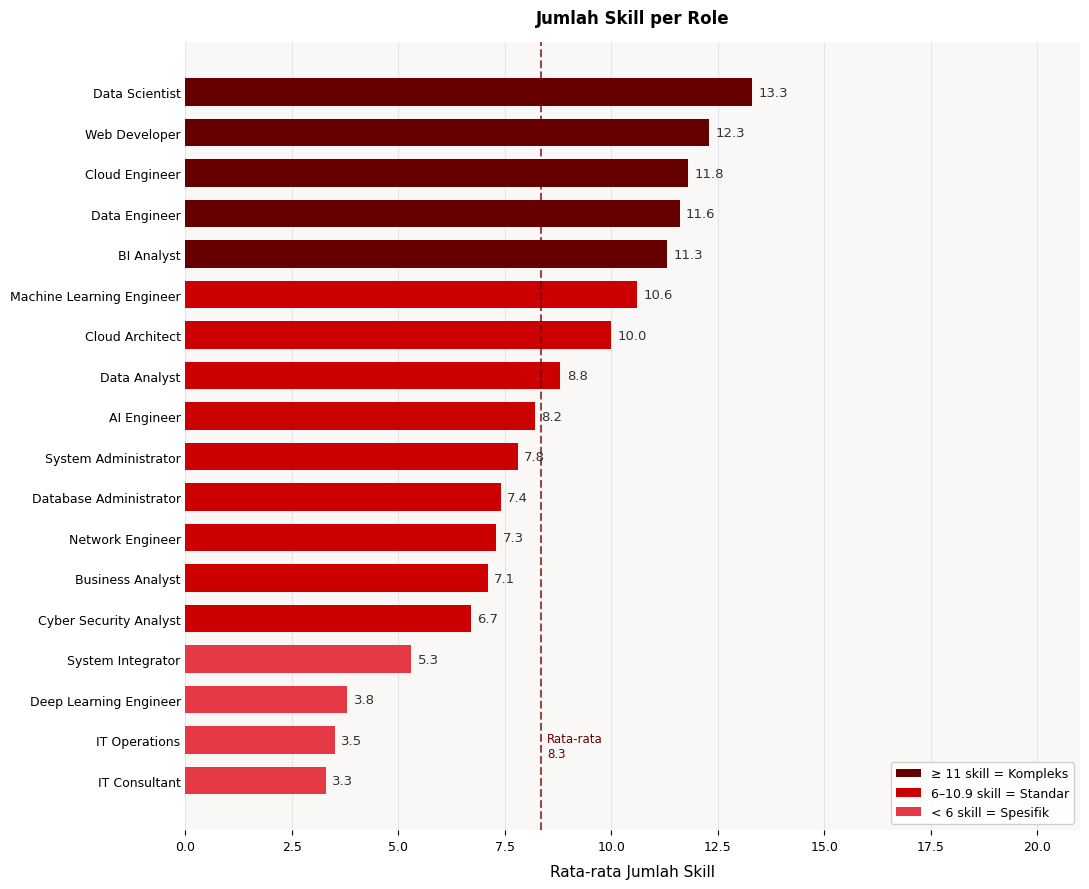

In [ ]:
df_jd['skill_count'] = df_jd['require_skills'].apply(lambda x: len([s for s in x if s.strip()]) if isinstance(x, list) else 0)
domain_avg = (df_jd.groupby('job_role')['skill_count'].mean().sort_values(ascending=True).round(1))

bar_colors = [
    RED_DARK[0] if v >= 11 else
    RED_DARK[2] if v >= 6 else
    RED_DARK[3]
    for v in domain_avg.values
]

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor(BG_LIGHT)

bars = ax.barh(domain_avg.index, domain_avg.values,color=bar_colors, height=0.68, zorder=2)
for bar, val in zip(bars, domain_avg.values):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f'{val}', va='center', ha='left', fontsize=9.5, color='#333')

mean_val = domain_avg.mean()
ax.axvline(mean_val, color=RED_DARK[0], linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(mean_val + 0.15, 0.5, f'Rata-rata\n{mean_val:.1f}', color=RED_DARK[0], fontsize=8.5, va='bottom')

legend_elements = [
    mpatches.Patch(facecolor=RED_DARK[0], label='≥ 11 skill = Kompleks'),
    mpatches.Patch(facecolor=RED_DARK[2], label='6–10.9 skill = Standar'),
    mpatches.Patch(facecolor=RED_DARK[3], label='< 6 skill = Spesifik')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

ax.set_xlabel('Rata-rata Jumlah Skill', labelpad=8)
ax.set_title('Jumlah Skill per Role',
             fontweight='bold', pad=14)
ax.set_xlim(0, 21)
ax.tick_params(axis='y', length=0)
ax.grid(True, axis='x', alpha=0.3, color='#bbbbd0')
for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.show()


**Insight**
- Berdasarkan visualisasi diatas, rata-rata jumlah skill yang dibutuhkan di seluruh profesi TI adalah 8,3 skill.Profesi dengan kebutuhan skill tertinggi adalah Data Scientist (13,3 skill), lalu diikuti oleh Web Developer (12,3 skill), dan Cloud Engineer (11,8 skill). Sementara itu,profesi dengan kebutuhan skill terendah adalah IT Consultant (3,3 skill) dan IT Operations (3,5 skill).

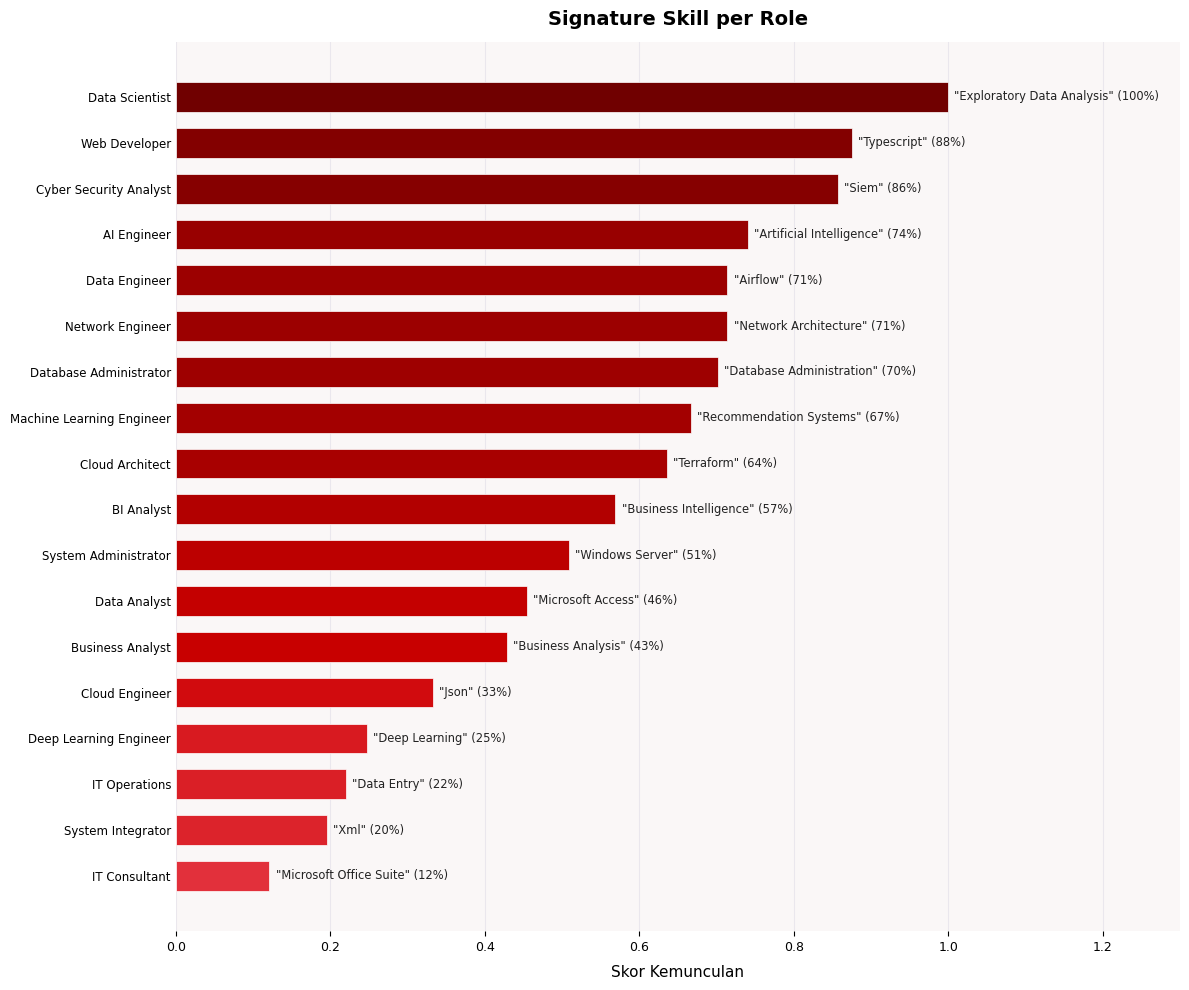

In [ ]:
total_jd_freq = df_jd_skills['skill'].value_counts()

domain_skill_freq = (df_jd_skills.groupby(['job_role', 'skill']).size().reset_index(name='domain_count'))
domain_skill_freq['global_count'] = (domain_skill_freq['skill'].map(total_jd_freq))
domain_skill_freq['specificity'] = (domain_skill_freq['domain_count'] / domain_skill_freq['global_count']).round(3)

sig_jd = (
    domain_skill_freq[domain_skill_freq['domain_count'] >= 5]
    .sort_values('specificity', ascending=False)
    .groupby('job_role')
    .first()
    .reset_index()
    [['job_role', 'skill', 'domain_count', 'specificity']]
    .sort_values('specificity', ascending=True)
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_dark",
    RED_DARK[::-1]
)

spec_colors = cmap(
    np.interp(sig_jd['specificity'], [0, 1], [0.2, 0.95])
)

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor(BG_LIGHT)
bars = ax.barh(
    sig_jd['job_role'],
    sig_jd['specificity'],
    color=spec_colors,
    height=0.65,
    edgecolor='white',
    linewidth=0.5,
    zorder=2
)

for bar, (_, row) in zip(bars, sig_jd.iterrows()):
    ax.text(
        bar.get_width() + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f'"{row["skill"].title()}" ({row["specificity"]:.0%})',
        va='center',
        ha='left',
        fontsize=8.3,
        color='#222'
    )

ax.set_xlabel('Skor Kemunculan',labelpad=8)
ax.set_title('Signature Skill per Role',fontsize=14,fontweight='bold',pad=12)
ax.set_xlim(0, 1.3)
ax.tick_params(axis='y', labelsize=8.5, length=0)
ax.grid(True, axis='x', alpha=0.25, color='#bbbbd0')
for sp in ax.spines.values():
    sp.set_visible(False)

plt.tight_layout()
plt.show()


**Insight**
- Berdasarkan visualisasi signature skill di atas, Data Scientist memiliki keunikan tertinggi dengan skill "Exploratory Data Analysis" yang muncul mutlak 100%. Diikuti oleh Web Developer dengan skill "Typescript" (88%) dan Cyber Security Analyst dengan skill "Siem" (86%). Sementara itu, IT Consultant memiliki skor kemunculan skill terendah, yaitu hanya sebesar 12% untuk "Microsoft Office Suite".

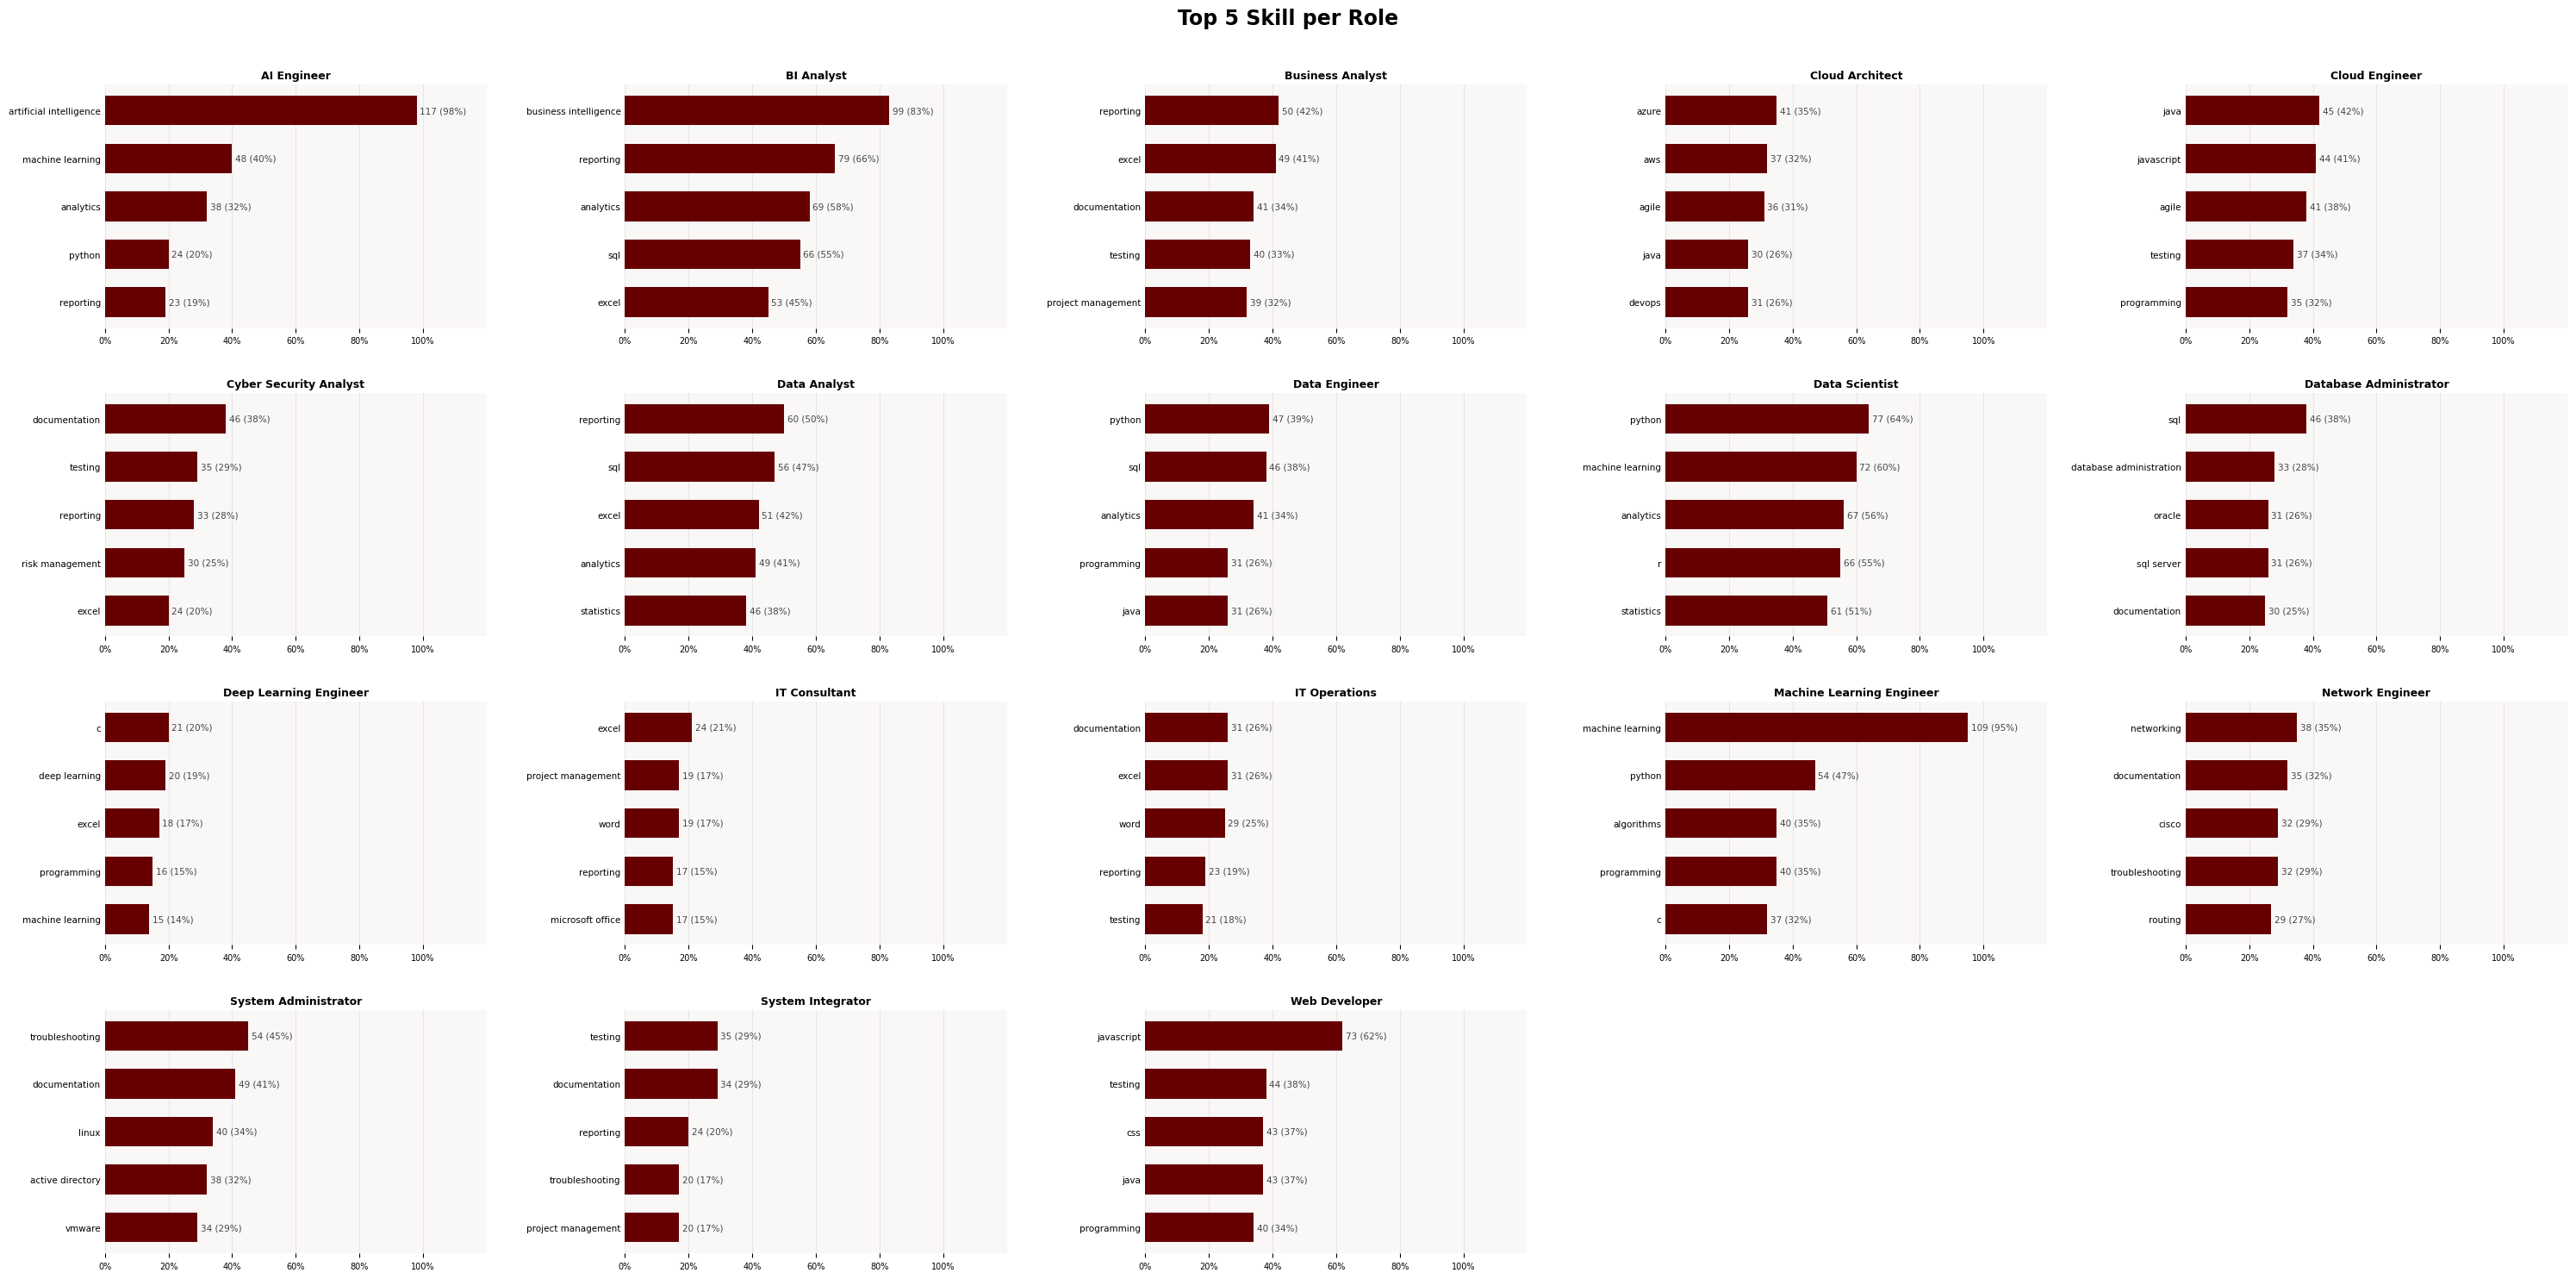

In [ ]:
top5_jd = (
    df_jd_skills.groupby(['job_role', 'skill'])
    .size()
    .reset_index(name='count')
    .sort_values(['job_role', 'count'], ascending=[True, False])
    .groupby('job_role')
    .head(5)
    .reset_index(drop=True)
)

domains_sorted = sorted(df_jd['job_role'].unique())

fig, axes = plt.subplots(5, 5, figsize=(30, 18))
fig.suptitle('Top 5 Skill per Role', fontsize=17, fontweight='bold', y=1.01)

for idx, domain in enumerate(domains_sorted):
    ax = axes[idx // 5][idx % 5]
    ax.set_facecolor(BG_LIGHT)

    data = (
        top5_jd[top5_jd['job_role'] == domain]
        .copy()
    )

    n_post = df_jd[df_jd['job_role'] == domain].shape[0]

    data['pct'] = (
        data['count'] / n_post * 100
    ).round(0).astype(int)

    data = data.sort_values('pct')

    ax.barh(
        data['skill'],
        data['pct'],
        height=0.62,
        color=RED_DARK[0],
        zorder=2
    )

    skill_list = data['skill'].tolist()

    for _, row in data.iterrows():
        ax.text(
            row['pct'] + 1,
            skill_list.index(row['skill']),
            f"{row['count']} ({row['pct']}%)",
            va='center',
            ha='left',
            fontsize=7.5,
            color='#444'
        )

    ax.set_title(
        domain,
        fontsize=9,
        fontweight='bold',
        pad=5
    )

    ax.set_xlim(0, 120)

    ax.set_xticks(range(0, 101, 20))
    ax.set_xticklabels([f'{i}%' for i in range(0, 101, 20)])

    ax.tick_params(axis='y', labelsize=7.5, length=0)
    ax.tick_params(axis='x', labelsize=7)

    ax.grid(
        True,
        axis='x',
        alpha=0.3,
        color='#bbbbd0'
    )

    for sp in ax.spines.values():
        sp.set_visible(False)

# Hide any remaining empty subplots
num_domains = len(domains_sorted)
total_rows, total_cols = axes.shape
total_plots = total_rows * total_cols

for i in range(num_domains, total_plots):
    row_idx = i // total_cols
    col_idx = i % total_cols
    axes[row_idx, col_idx].set_visible(False)

plt.tight_layout(h_pad=2.8, w_pad=2)
plt.show()

### **Kesimpulan**

**1. Skill yang Mendominasi Secara Keseluruhan**

Python, SQL, Analytics, Reporting, dan Excel muncul pada banyak role dalam dataset. Hal ini menunjukkan bahwa skill tersebut tidak hanya dibutuhkan pada role yang berfokus pada data, tetapi juga pada berbagai posisi IT lainnya.

**2. Skill yang Bersifat Role Spesifik**

Beberapa skill memiliki ikatan yang sangat kuat dan spesifik pada role tertentu:

* Artificial Intelligence → AI Engineer
* Machine Learning → Machine Learning Engineer
* Business Intelligence → BI Analyst
* Javascript → Web Developer
* Azure / AWS → Cloud Architect
* Linux / VMware → System Administrator

Pola ini menunjukkan bahwa setiap profesi tetap memiliki keahlian inti unik yang membedakannya secara jelas dari role lain.

**3. Frekuensi Kemunculan vs Keunikan**

Beberapa skill seperti Python dan Excel, muncul pada banyak role sehingga tidak terlalu mencerminkan role tertentu. Sebaliknya, skill seperti Artificial Intelligence dan Machine Learning lebih sering ditemukan pada role tertentu dan jarang muncul pada role lainnya.

### **Action Item:**
> Hasil analisis menunjukkan bahwa beberapa skill memiliki keterkaitan yang kuat dengan role tertentu. Oleh karena itu, perusahaan dapat lebih menonjolkan skill spesifik yang benar-benar dibutuhkan dalam job posting, sementara skill yang umum ditemukan di berbagai role dapat dijadikan persyaratan tambahan.

## **Pertanyaan 2: Bagaimana karakteristik kepemilikan skill kandidat pada berbagai role IT?**

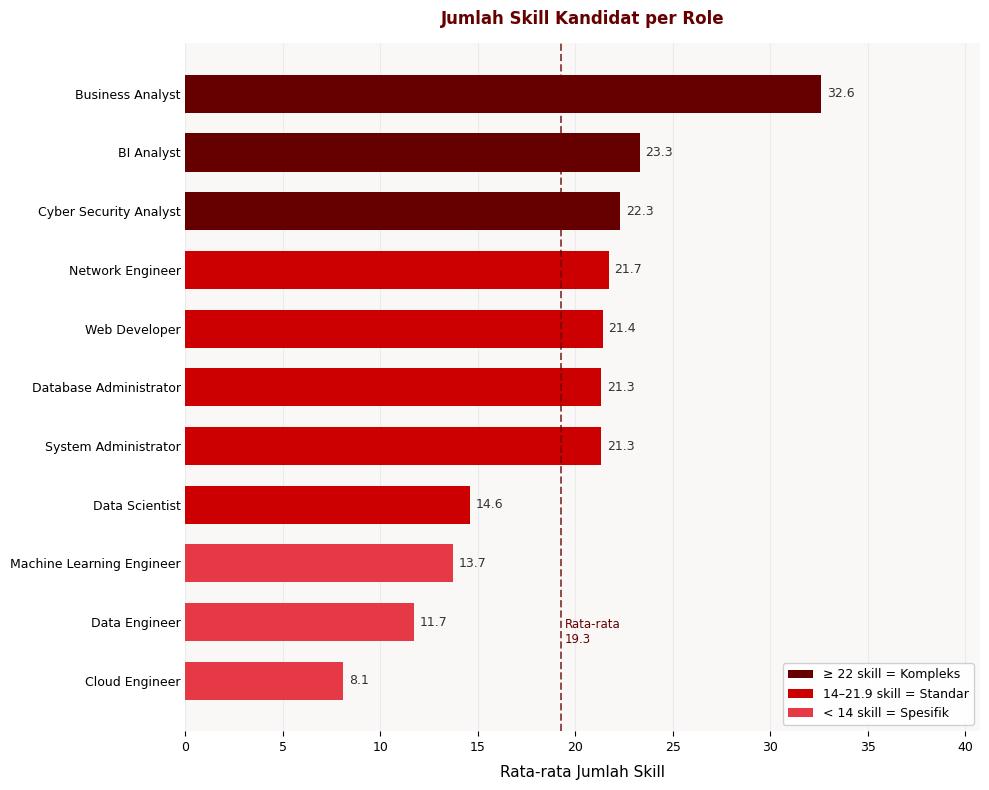

In [ ]:
df_cv['skill_count'] = df_cv['skills'].apply(lambda x: len([s for s in x if s.strip()] if isinstance(x, list) else []))
role_avg = (df_cv.groupby('cv_role')['skill_count'].mean().sort_values(ascending=True).round(1))

bar_colors = [
    RED_DARK[0] if v >= 22 else
    RED_DARK[2] if v >= 14 else
    RED_DARK[3]
    for v in role_avg.values
]

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor(BG_LIGHT)

bars = ax.barh(role_avg.index, role_avg.values, color=bar_colors, height=0.65, zorder=2)
for bar, val in zip(bars, role_avg.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val}', va='center', ha='left', fontsize=9, color='#333')

mean_cv = role_avg.mean()
ax.axvline(mean_cv, color=RED_DARK[0], linestyle='--', linewidth=1.4, alpha=0.7)
ax.text(mean_cv + 0.2, 0.6, f'Rata-rata\n{mean_cv:.1f}',
        color=RED_DARK[0], fontsize=8.5, va='bottom')

legend_elements = [
    mpatches.Patch(facecolor=RED_DARK[0], label='≥ 22 skill = Kompleks'),
    mpatches.Patch(facecolor=RED_DARK[2], label='14–21.9 skill = Standar'),
    mpatches.Patch(facecolor=RED_DARK[3], label='< 14 skill = Spesifik')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

ax.set_xlabel('Rata-rata Jumlah Skill', labelpad=8)
ax.set_title('Jumlah Skill Kandidat per Role',fontweight='bold', pad=14, color=RED_DARK[0])
ax.set_xlim(0, role_avg.max() * 1.25)
ax.tick_params(axis='y', length=0)
ax.grid(True, axis='x', alpha=0.3, color='#c5cfe6')
for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.show()


**Insight**
- Berdasarkan visualisasi di atas, rata-rata jumlah skill yang dimiliki kandidat di seluruh profesi TI adalah 19,3 skill. Kandidat dengan rata-rata skill tertinggi adalah Business Analyst (32,6 skill), lalu diikuti oleh BI Analyst (23,3 skill) dan Cyber Security Analyst (22,3 skill). Sementara itu, kandidat dengan rata-rata skill terendah adalah Cloud Engineer (8,1 skill) dan Data Engineer (11,7 skill).

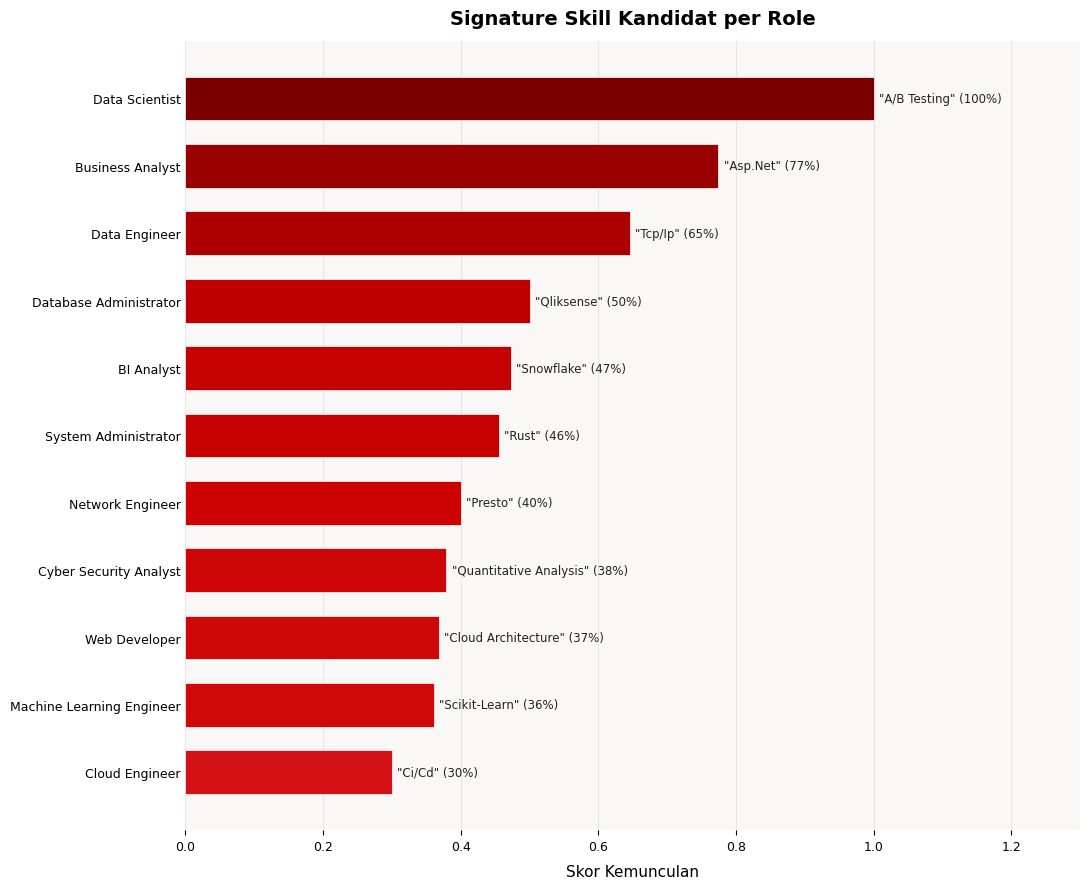

In [ ]:
total_cv_freq = df_cv_skills['skill'].value_counts()
role_skill_freq = (df_cv_skills.groupby(['cv_role', 'skill']).size().reset_index(name='role_count'))
role_skill_freq['global_count'] = (role_skill_freq['skill'].map(total_cv_freq))
role_skill_freq['specificity'] = (role_skill_freq['role_count'] / role_skill_freq['global_count']).round(3)

sig_cv = (
    role_skill_freq[role_skill_freq['role_count'] >= 3]
    .sort_values('specificity', ascending=False)
    .groupby('cv_role')
    .first()
    .reset_index()
    [['cv_role', 'skill', 'role_count', 'specificity']]
    .sort_values('specificity', ascending=True)
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_dark",
    RED_DARK[::-1]
)

spec_colors_cv = cmap(
    np.interp(sig_cv['specificity'], [0, 1], [0.22, 0.9])
)

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor(BG_LIGHT)

bars = ax.barh(
    sig_cv['cv_role'],
    sig_cv['specificity'],
    color=spec_colors_cv,
    height=0.65,
    edgecolor='white',
    linewidth=0.5,
    zorder=2
)

for bar, (_, row) in zip(bars, sig_cv.iterrows()):
    ax.text(
        bar.get_width() + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f'"{row["skill"].title()}" ({row["specificity"]:.0%})',
        va='center',
        ha='left',
        fontsize=8.5,
        color='#222'
    )

ax.set_xlabel('Skor Kemunculan',labelpad=8)
ax.set_title('Signature Skill Kandidat per Role',fontsize=14,fontweight='bold',pad=12)

ax.set_xlim(0, 1.3)
ax.tick_params(axis='y', labelsize=9, length=0)
ax.grid(True, axis='x', alpha=0.3, color='#bbbbd0')
for sp in ax.spines.values():
    sp.set_visible(False)

plt.tight_layout()
plt.show()


**Insight**
- Berdasarkan visualisasi di atas, kandidat Data Scientist memiliki keunikan tertinggi dengan skill "A/B Testing" yang muncul mutlak sebesar 100%. Diikuti oleh kandidat Business Analyst dengan skill "Asp.Net" (77%) dan Data Engineer dengan "Tcp/Ip" (65%). Sementara itu, kandidat Cloud Engineer memiliki skor kemunculan signature skill terendah, yaitu sebesar 30% untuk skill "Ci/Cd".

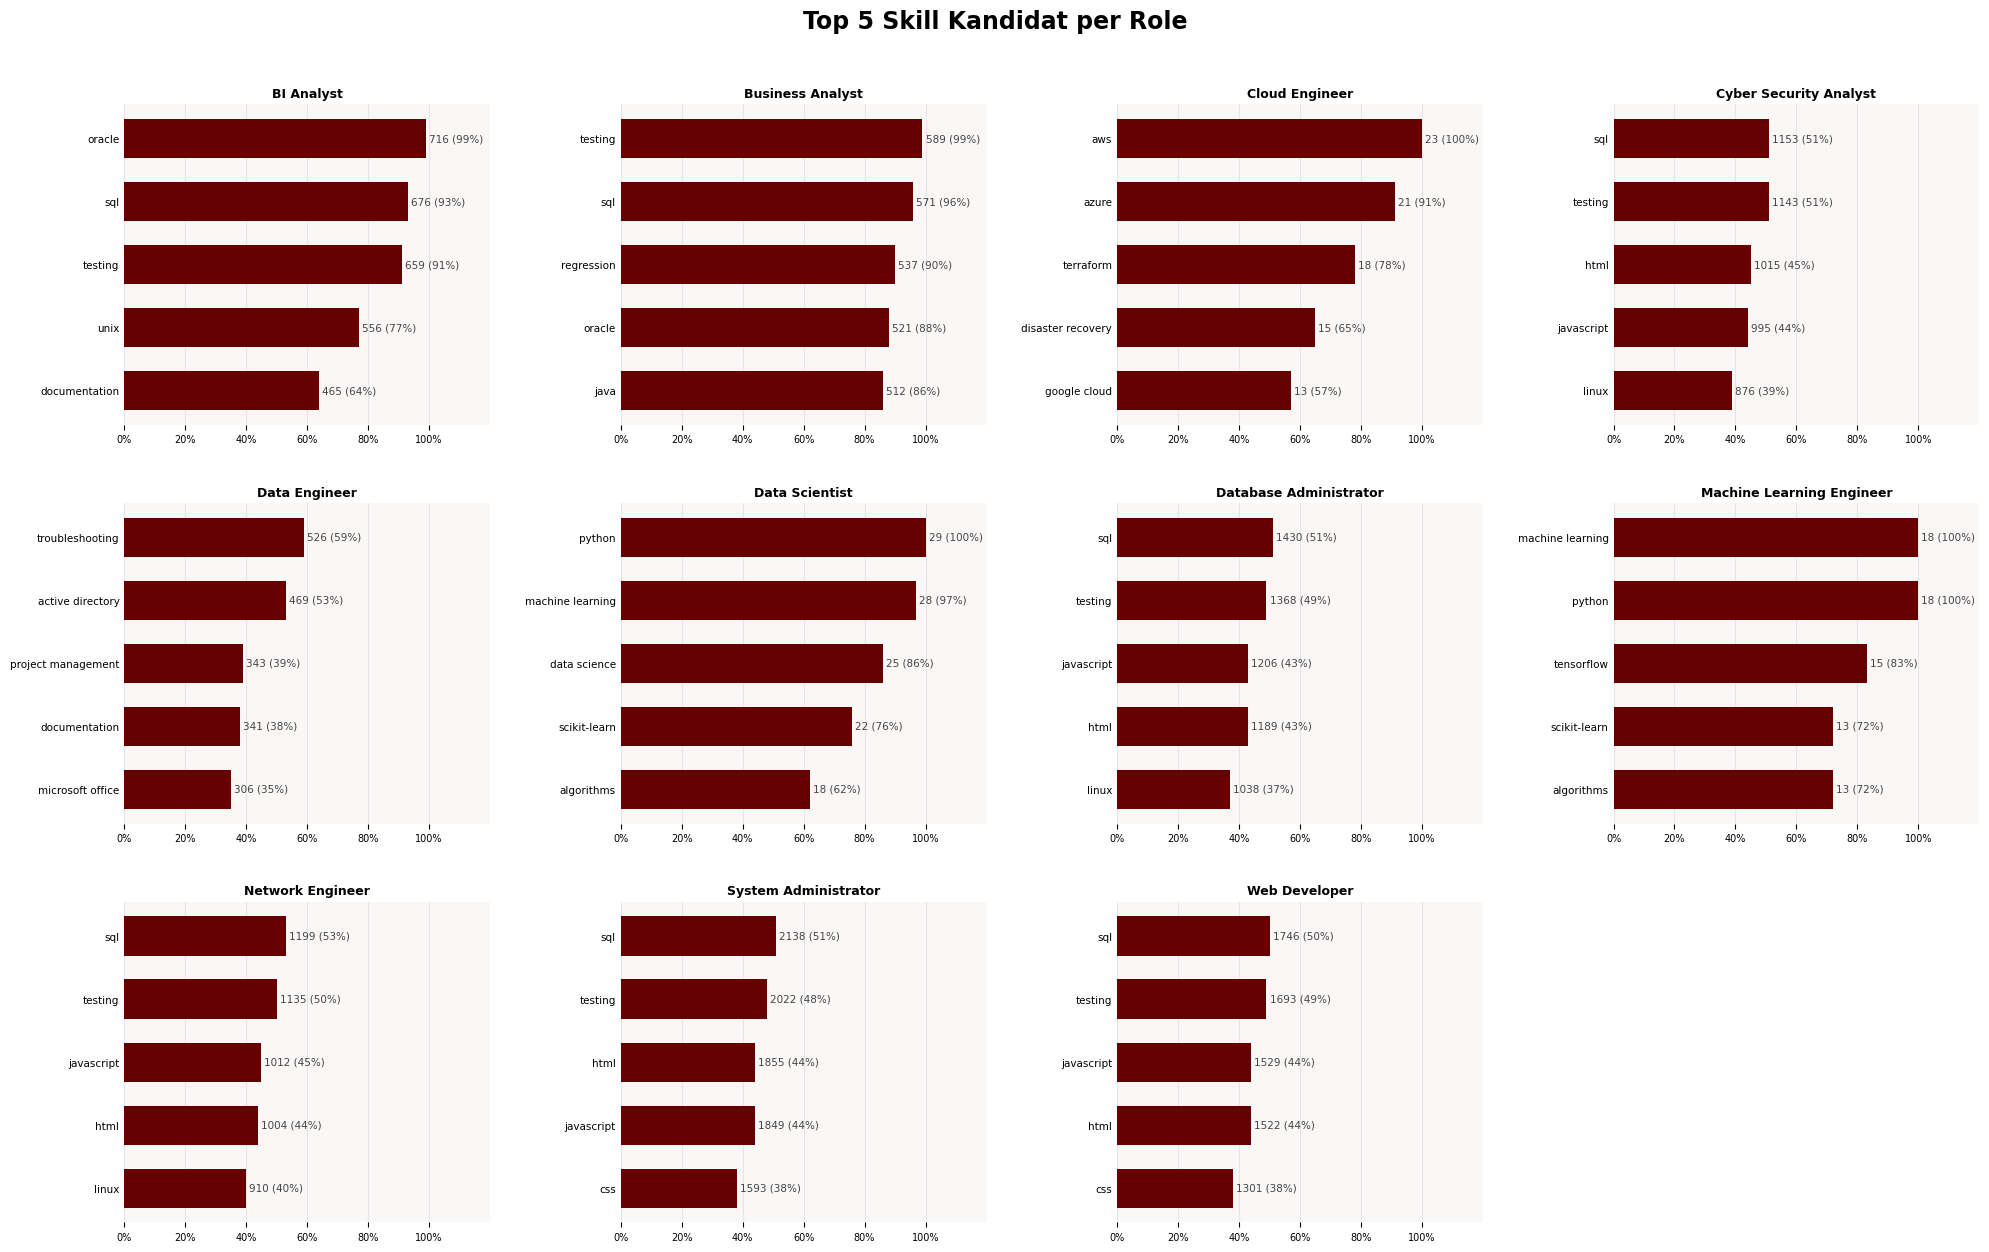

In [ ]:
top5_cv = (
    df_cv_skills.groupby(['cv_role', 'skill'])
    .size()
    .reset_index(name='count')
    .sort_values(['cv_role', 'count'], ascending=[True, False])
    .groupby('cv_role')
    .head(5)
    .reset_index(drop=True)
)

roles_sorted = sorted(df_cv['cv_role'].unique())

fig, axes = plt.subplots(6, 4, figsize=(20, 24))
fig.suptitle('Top 5 Skill Kandidat per Role', fontsize=17, fontweight='bold', y=1.01)

for idx, role in enumerate(roles_sorted):
    ax = axes[idx // 4][idx % 4]
    ax.set_facecolor(BG_LIGHT)

    data = (
        top5_cv[top5_cv['cv_role'] == role]
        .sort_values('pct' if 'pct' in top5_cv.columns else 'count')
        .copy()
    )

    n_cv = df_cv[df_cv['cv_role'] == role].shape[0]

    data['pct'] = (
        data['count'] / n_cv * 100
    ).round(0).astype(int)

    data = data.sort_values('pct')

    ax.barh(
        data['skill'],
        data['pct'],
        color=RED_DARK[0],
        height=0.62,
        zorder=2
    )

    skill_list = data['skill'].tolist()

    for _, row in data.iterrows():
        ax.text(
            row['pct'] + 1,
            skill_list.index(row['skill']),
            f"{row['count']} ({row['pct']}%)",
            va='center',
            ha='left',
            fontsize=7.5,
            color='#444'
        )

    ax.set_title(
        f'{role}',
        fontsize=9,
        fontweight='bold',
        pad=5
    )

    ax.set_xlim(0, 120)

    ax.set_xticks(range(0, 101, 20))
    ax.set_xticklabels([f'{i}%' for i in range(0, 101, 20)])

    ax.tick_params(axis='y', labelsize=7.5, length=0)
    ax.tick_params(axis='x', labelsize=7)

    ax.grid(
        True,
        axis='x',
        alpha=0.3,
        color='#bbbbd0'
    )

    for sp in ax.spines.values():
        sp.set_visible(False)

for idx in range(len(roles_sorted), 24):
    axes[idx // 4][idx % 4].set_visible(False)

plt.tight_layout(h_pad=3, w_pad=2.5)
plt.show()

### **Kesimpulan**

**1. Skill Terpopuler**

SQL dan Testing merupakan skill yang paling sering muncul pada berbagai role kandidat, termasuk System Administrator, Network Engineer, Web Developer, dan BI Analyst. Selain itu, HTML dan JavaScript juga termasuk skill yang banyak dicantumkan oleh kandidat di beberapa role.

**2. Variasi Jumlah Skill per Role**

Kandidat pada role Business Analyst memiliki rata-rata jumlah skill tertinggi di CV mereka, yaitu sebesar 32,6 skill, disusul oleh BI Analyst (23,3 skill). Sebaliknya, kandidat pada role Cloud Engineer tercatat memiliki rata-rata jumlah skill paling sedikit, yaitu hanya sebesar 8,1 skill, yang mengindikasikan bahwa profil pelamar di bidang cloud cenderung lebih terspesialisasi pada rumpun keahlian yang spesifik.

**3. Pola Signature Skill Kandidat**

Beberapa role memiliki skill yang sangat dominan dibandingkan role lainnya. Misalnya, seluruh kandidat Data Scientist dalam dataset mencantumkan A/B Testing pada CV mereka, sementara ASP.NET muncul pada 77% kandidat Business Analyst. Temuan ini menunjukkan bahwa skill tersebut cukup kuat dalam merepresentasikan masing-masing role.

### **Action Item:**
> Hasil analisis menunjukkan bahwa skill umum seperti SQL dan Testing muncul pada banyak kandidat di berbagai role. Oleh karena itu, perusahaan dapat mempertimbangkan skill yang lebih spesifik untuk proses penyaringan awal. Contohnya, A/B Testing pada Data Scientist atau ASP.NET pada Business Analyst, karena skill tersebut lebih mencerminkan karakteristik masing-masing role.

## Pertanyaan 3: Bagaimana gap skill antara Kebutuhan Industri dengan Kandidat?

In [ ]:
jd_freq = df_jd_skills["skill"].value_counts().reset_index()
jd_freq.columns = ["skill", "jd_count"]
cv_freq = df_cv_skills["skill"].value_counts().reset_index()
cv_freq.columns = ["skill", "cv_count"]
gap_df = pd.merge(jd_freq, cv_freq, on="skill", how="inner")

gap_df["jd_pct"]  = (gap_df["jd_count"] / gap_df["jd_count"].sum()) * 100
gap_df["cv_pct"]  = (gap_df["cv_count"] / gap_df["cv_count"].sum()) * 100
gap_df["gap_score"] = ((gap_df["cv_pct"] / gap_df["jd_pct"]).round(5)) *100
gap_df["gap_score"] = (100 - gap_df["gap_score"])

high_gap = (
    gap_df[gap_df["gap_score"] > 0]
    .sort_values("gap_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
low_gap = (
    gap_df[gap_df["gap_score"] > 0]
    .sort_values("gap_score", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

print("TOP 10 SKILL GAP TERTINGGI")
print(high_gap[
        ["skill", "jd_pct", "cv_pct", "gap_score"]
    ].to_string(index=False))
print("\n")
print("TOP 10 SKILL GAP TERENDAH")
print(low_gap[
        ["skill", "jd_pct", "cv_pct", "gap_score"]
    ].to_string(index=False))

TOP 10 SKILL GAP TERTINGGI
                  skill   jd_pct   cv_pct  gap_score
                node.js 0.244721 0.002988     98.779
            a/b testing 0.068294 0.001358     98.012
                 looker 0.102442 0.002716     97.349
    operations research 0.170736 0.005432     96.818
artificial intelligence 0.899209 0.029333     96.738
                  ci/cd 0.182118 0.008148     95.526
  quantitative analysis 0.170736 0.007876     95.387
 reinforcement learning 0.125206 0.006247     95.011
       data engineering 0.239030 0.012765     94.660
        computer vision 0.261795 0.014938     94.294


TOP 10 SKILL GAP TERENDAH
              skill   jd_pct   cv_pct  gap_score
          switching 0.176427 0.174638      1.014
               siem 0.119515 0.117330      1.828
      elasticsearch 0.073986 0.072517      1.985
incident management 0.130898 0.127651      2.480
                  c 1.485402 1.438384      3.165
         data entry 0.233339 0.223797      4.089
           aws glue

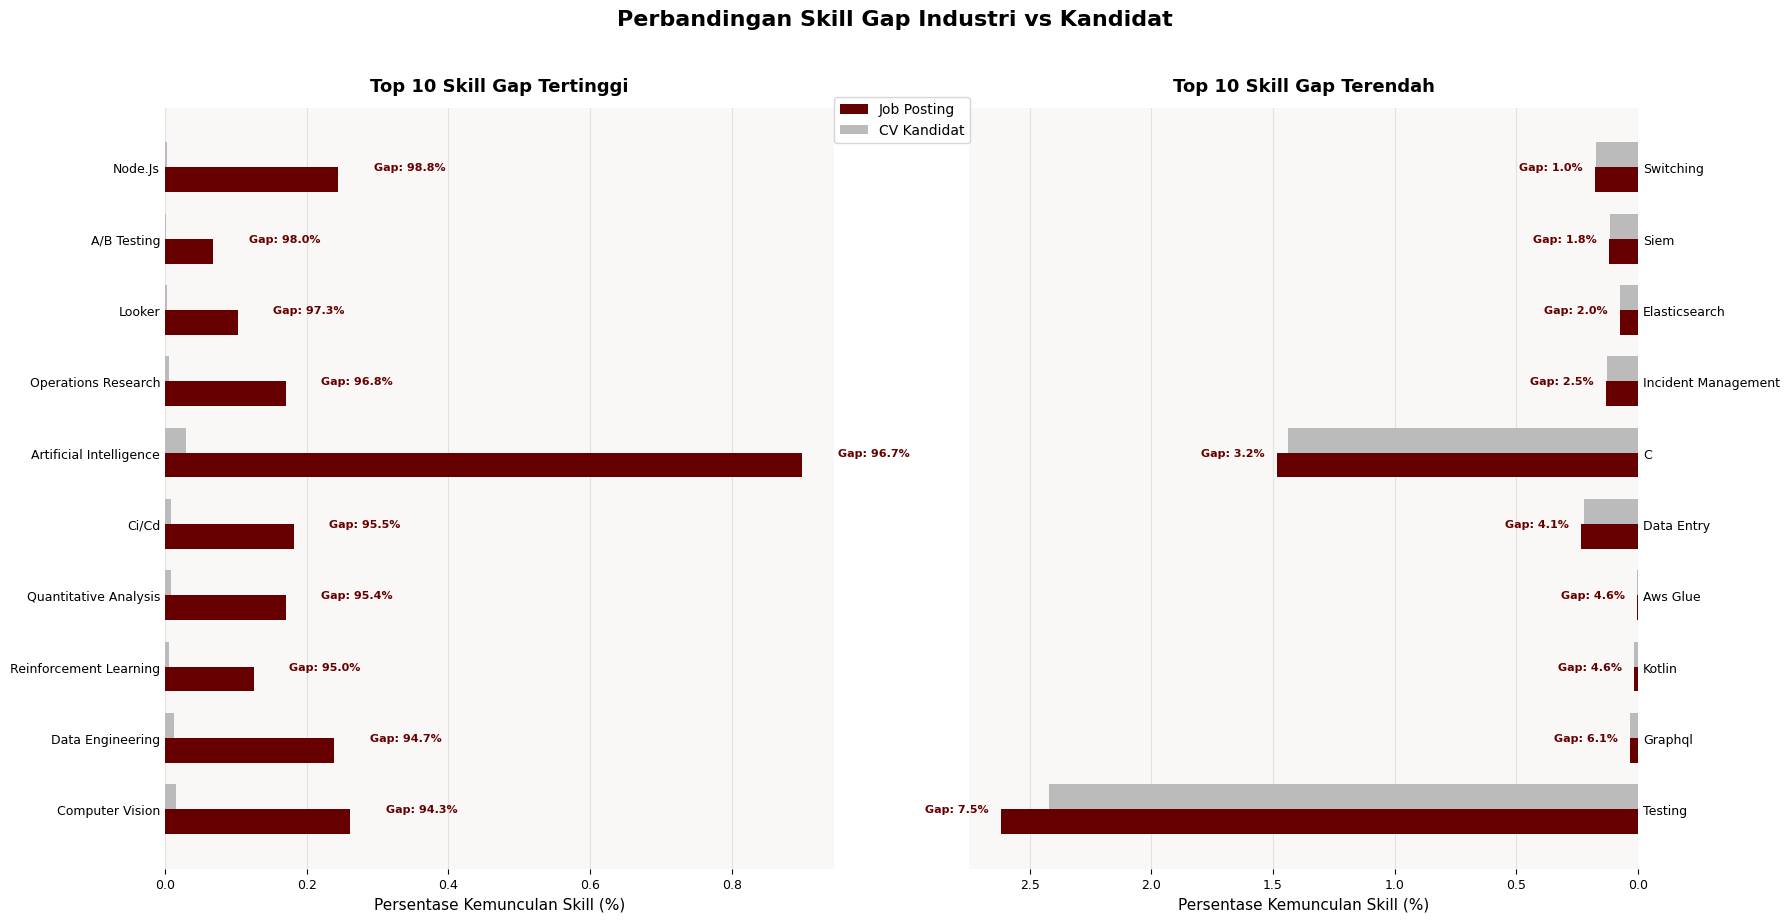

In [ ]:
n = len(high_gap)
colors_jd = make_gradient(n)
colors_cv = ["#c8c8c8"] * n

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
datasets = [
    (high_gap, "Top 10 Skill Gap Tertinggi"),
    (low_gap, "Top 10 Skill Gap Terendah")
]

for idx, (ax, (data, title)) in enumerate(zip(axes, datasets)):
    ax.set_facecolor(BG_LIGHT)
    y = np.arange(len(data))
    height = 0.35

    if idx == 0:
        ax.barh(
            y + height/2,
            data["jd_pct"],
            height=height,
            color=RED_DARK[0],
            label="Job Posting",
            zorder=2
        )
        ax.barh(
            y - height/2,
            data["cv_pct"],
            height=height,
            color="#BBBBBB",
            label="CV Kandidat",
            zorder=2
        )
        for i, (_, row) in enumerate(data.iterrows()):
            x_pos = max(row["jd_pct"], row["cv_pct"]) + 0.05
            ax.text(
                x_pos,
                i,
                f"Gap: {row['gap_score']:.1f}%",
                va="center",
                ha="left",
                fontsize=8,
                color=RED_DARK[0],
                fontweight="bold"
            )
        ax.set_yticks(y)
        ax.set_yticklabels(
            data["skill"].str.title(),
            fontsize=9
        )

    else:
        ax.barh(
            y + height/2,
            -data["jd_pct"],
            height=height,
            color=RED_DARK[0],
            label="Job Posting",
            zorder=2
        )
        ax.barh(
            y - height/2,
            -data["cv_pct"],
            height=height,
            color="#BBBBBB",
            label="CV Kandidat",
            zorder=2
        )
        for i, (_, row) in enumerate(data.iterrows()):
            x_pos = -max(row["jd_pct"], row["cv_pct"]) - 0.05
            ax.text(
                x_pos,
                i,
                f"Gap: {row['gap_score']:.1f}%",
                va="center",
                ha="right",
                fontsize=8,
                color=RED_DARK[0],
                fontweight="bold"
            )

        ax.set_yticks(y)
        ax.set_yticklabels(
            data["skill"].str.title(),
            fontsize=9
        )
        ax.yaxis.tick_right()
        xticks = ax.get_xticks()
        ax.set_xticklabels([abs(x) for x in xticks])

    ax.invert_yaxis()
    ax.set_xlabel("Persentase Kemunculan Skill (%)")
    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold",
        pad=12
    )
    ax.grid(True, axis="x", alpha=0.3)
    ax.tick_params(axis="y", length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.504, 0.93), ncol=1)
plt.suptitle(
    "Perbandingan Skill Gap Industri vs Kandidat",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### **Kesimpulan**

**1. Skill dengan Gap Terbesar**

Kesenjangan (gap) tertinggi antara kebutuhan industri (job posting) dan ketersediaan di CV kandidat didominasi bidang pengembangan web dan AI/Data. Nilai gap terbesar adalah Node.js (98,8%), diikuti oleh A/B Testing (98,0%), Looker (97,3%), Operations Research (96,8%), dan Artificial Intelligence (96,7%). Hal ini mengindikasikan bahwa laju adopsi teknologi spesifik di industri bergerak jauh lebih cepat dibandingkan pembaruan keahlian yang dimiliki oleh mayoritas kandidat.

**2. Skill dengan Gap Terkecil**

Kebutuhan industri dan ketersediaan kandidat sudah sangat selaras pada beberapa skill teknis mendasar maupun spesifik. Nilai kesenjangan paling rendah ditemukan pada skill Switching (1,0%), Siem (1,8%), Elasticsearch (2,0%), Incident Management (2,5%), serta bahasa pemrograman C (3,2%). Kecilnya angka gap ini menunjukkan bahwa suplai kandidat di pasar kerja sudah cukup memenuhi standar kebutuhan yang dicari oleh perusahaan untuk kompetensi tersebut.


### **Action Item:**
> Skill seperti Node.js, A/B Testing, Looker, dan Artificial Intelligence memiliki tingkat kebutuhan yang tinggi di industri, namun masih relatif jarang ditemukan pada kandidat. Kondisi ini menunjukkan bahwa penguasaan skill tersebut berpotensi memberikan nilai tambah bagi kandidat yang ingin meningkatkan daya saing di pasar kerja.

> Beberapa skill menunjukkan gap yang cukup besar antara kebutuhan industri dan ketersediaan kandidat. Hal ini menandakan bahwa perusahaan mungkin akan menghadapi tantangan dalam mencari kandidat yang sesuai untuk kompetensi tersebut, sehingga diperlukan strategi rekrutmen atau pelatihan yang lebih terarah.
